In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from utils.eval.vis import plt_setup_latex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


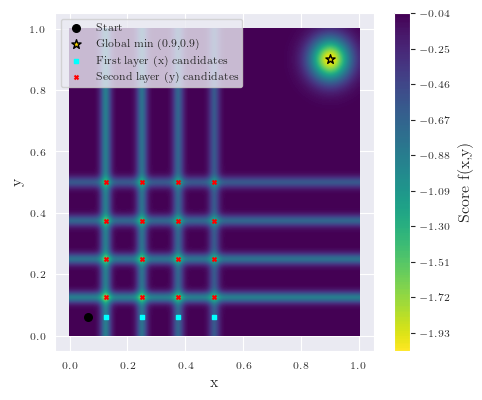

First-layer (x) candidates:
 1: (x=0.125, y=0.062), score=-0.8900
 2: (x=0.250, y=0.062), score=-0.7900
 3: (x=0.375, y=0.062), score=-0.6900
 4: (x=0.500, y=0.062), score=-0.5900

Second-layer (y) candidates (for all x):
 1: (x=0.125, y=0.125), score=-1.7400
 2: (x=0.125, y=0.250), score=-1.6400
 3: (x=0.125, y=0.375), score=-1.5400
 4: (x=0.125, y=0.500), score=-1.4400
 5: (x=0.250, y=0.125), score=-1.6400
 6: (x=0.250, y=0.250), score=-1.5400
 7: (x=0.250, y=0.375), score=-1.4400
 8: (x=0.250, y=0.500), score=-1.3400
 9: (x=0.375, y=0.125), score=-1.5400
 10: (x=0.375, y=0.250), score=-1.4400
 11: (x=0.375, y=0.375), score=-1.3400
 12: (x=0.375, y=0.500), score=-1.2400
 13: (x=0.500, y=0.125), score=-1.4400
 14: (x=0.500, y=0.250), score=-1.3400
 15: (x=0.500, y=0.375), score=-1.2400
 16: (x=0.500, y=0.500), score=-1.1400


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

W= plt_setup_latex()

# --- Define score function ---

axis_positions = np.array([0.125, 0.25, 0.375, 0.5])
axis_heights = np.array([0.85, 0.75, 0.65, 0.55])

def g_axis(x):
    val = np.zeros_like(x)
    for c, h in zip(axis_positions, axis_heights):
        val += h * np.exp(-((x - c) / 0.02) ** 2)
    val += 0.02
    return val

def h_interaction(X, Y):
    cx, cy = 0.9, 0.9
    amp = 2.0
    wx, wy = 0.05, 0.05
    return amp * np.exp(-0.5 * (((X - cx) / wx) ** 2 + ((Y - cy) / wy) ** 2))

def f(X, Y):
    return -g_axis(X) - g_axis(Y) - h_interaction(X, Y)

# --- Grid and base setup ---
grid_n = 300
X = np.linspace(0, 1, grid_n)
Y = np.linspace(0, 1, grid_n)
XX, YY = np.meshgrid(X, Y)
ZZ = f(XX, YY)

# --- Search logic ---
start = (0.0625, 0.0625)
global_loc = (0.9, 0.9)
r = 1.0
k = 4  # easily change to increase candidates

def limited_1d_search(curr_coord, fixed_other, r, axis='x'):
    low = max(0.0, curr_coord - r)
    high = min(1.0, curr_coord + r)
    samp = np.linspace(low, high, 801)
    vals = f(samp, np.full_like(samp, fixed_other)) if axis == 'x' else f(np.full_like(samp, fixed_other), samp)
    minima_idx = [i for i in range(1, len(vals) - 1) if vals[i] < vals[i - 1] and vals[i] < vals[i + 1]]
    candidates = [(samp[i], vals[i]) for i in minima_idx]
    candidates.sort(key=lambda z: z[1])  # sort ascending (lower = better since we minimized)
    return candidates

# --- First layer (x) search ---
x_candidates = limited_1d_search(start[0], start[1], r, axis='x')
x_hypotheses = [(x, start[1], val) for x, val in x_candidates[:k]]

# --- Second layer (y) search for *each* x-hypothesis ---
y_hypotheses = []
for x, y, _ in x_hypotheses:
    ycands = limited_1d_search(start[1], x, r, axis='y')
    for yv, vv in ycands[:k]:
        y_hypotheses.append((x, yv, vv))

# --- Plot ---
fig, ax = plt.subplots(figsize=(W,W*5/6))
cs = ax.contourf(XX, YY, ZZ, levels=200, cmap='viridis_r')
fig.colorbar(cs, ax=ax, label='Score f(x,y)')

# Start and global
ax.scatter(*start, c='k', s=30, marker='o', label='Start')
ax.scatter(*global_loc, c='gold', s=48, marker='*', edgecolors='black', label='Global min (0.9,0.9)')

# First-layer (x) candidates
ax.scatter([x for x, _, _ in x_hypotheses], [start[1]] * len(x_hypotheses),
           marker='s', s=8, c='cyan', label='First layer (x) candidates')

# All second-layer (y) candidates for all x
if y_hypotheses:
    ax.scatter([x for x, _, _ in y_hypotheses],
               [y for _, y, _ in y_hypotheses],
               marker='x', s=8, c='red', label='Second layer (y) candidates')


figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "additional_visualization")
os.makedirs(figure_path, exist_ok=True)
# Visual details
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "two_layer_search_example.pgf"))
plt.savefig(os.path.join(figure_path, "two_layer_search_example.pdf"))
plt.show()

# Print confirmation
print("First-layer (x) candidates:")
for i, (x, y, val) in enumerate(x_hypotheses, start=1):
    print(f" {i}: (x={x:.3f}, y={y:.3f}), score={val:.4f}")

print("\nSecond-layer (y) candidates (for all x):")
for i, (x, y, val) in enumerate(y_hypotheses, start=1):
    print(f" {i}: (x={x:.3f}, y={y:.3f}), score={val:.4f}")


In [3]:
import torch
def matrix(self, param: torch.Tensor) -> torch.Tensor:
        """
        Args:
            param: Tensor of shape (..., 6), split into two 3D vectors.
        Returns:
            Homogeneous (...,4,4) rotation matrices.
        """
        batch = param.shape[:-1]
        a1, a2 = param[..., :3], param[..., 3:6]

        # --- CORRECTED GRAM-SCHMIDT ---
        # 1. Normalize the first vector
        b1 = a1 / torch.clamp(a1.norm(dim=-1, keepdim=True), min=1e-8)

        # 2. Project a2 onto b1
        proj = (b1 * a2).sum(-1, keepdim=True) * b1

        # 3. Get the orthogonal component (v2)
        v2 = a2 - proj

        # 4. Normalize the orthogonal component to get b2
        b2 = v2 / torch.clamp(v2.norm(dim=-1, keepdim=True), min=1e-8)

        # 5. Get the third vector
        b3 = torch.cross(b1, b2, dim=-1)
        # --- END CORRECTION ---

        # Assemble 3×3 and embed into 4×4
        R = torch.stack([b1, b2, b3], dim=-1)  # (...,3,3)


        return R
from torch.nn import functional as F
def rotation_6d_to_matrix(d6):
    a1 = d6[..., :3]
    a2 = d6[..., 3:]

    b1 = F.normalize(a1, dim=-1)
    b2 = F.normalize(a2 - (b1 * a2).sum(-1, keepdim=True) * b1, dim=-1)
    b3 = torch.cross(b1, b2, dim=-1)
    return torch.stack((b1, b2, b3), dim=-1)

#compare the twp

p = torch.randn(10,6)
R1 = matrix(None,p)
R2 = rotation_6d_to_matrix(p)
print(torch.allclose(R1,R2))

True


In [4]:
#print pytorch version
print(torch.__version__)

2.8.0+cu126


In [5]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [6]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [7]:
dataset ="bigger_mnist"
architecture = "resnet_small"

In [8]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data)


In [9]:
dataset_dict.keys()

dict_keys(['train_dataset', 'val_dataset', 'test_dataset', 'train_loader', 'train_loader_no_shuffle', 'val_loader', 'test_loader', 'shuffle_val_loader', 'n_classes', 'train_loader_transformed', 'train_loader_transformed_no_shuffle', 'val_loader_transformed', 'test_loader_transformed', 'shuffle_val_loader_transformed', 'train_loader_augmented'])

In [10]:
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']



In [11]:
batch_size = next(iter(train_loader))[0].shape[0]

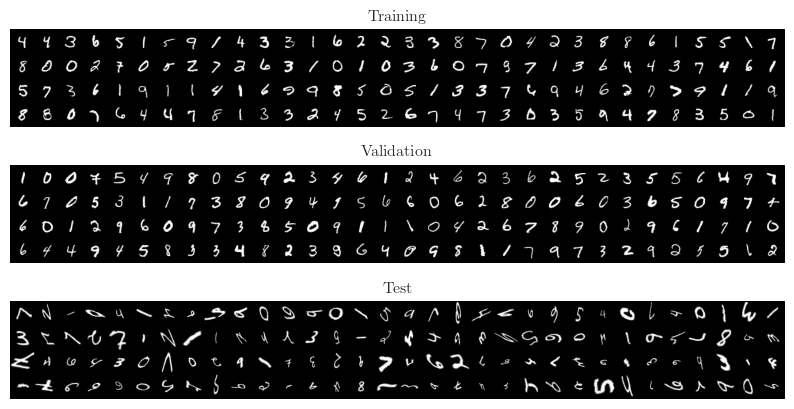

In [12]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [13]:
architecture_list_normal = ["resnet_small"]
equivariant_architecture_list = ["equivariant_resnet_small"]

In [14]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

In [15]:
input_size = dataset_info.input_size

In [16]:
rand_input = torch.randn(1, *input_size).to(device)

In [17]:
for arch in architecture_list_normal:
    from torchinfo import summary
    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=4).to(device)
    res = summary(model, input_size=(1,*input_size),col_names=["input_size", "output_size", "num_params", "trainable","kernel_size"], device=device.type)
    print(res)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable                 Kernel Shape
FlexibleResNet                                [1, 1, 40, 40]            [1, 10]                   --                        True                      --
├─Conv2d: 1-1                                 [1, 1, 40, 40]            [1, 64, 20, 20]           576                       True                      [3, 3]
├─BatchNorm2d: 1-2                            [1, 64, 20, 20]           [1, 64, 20, 20]           128                       True                      --
├─GELU: 1-3                                   [1, 64, 20, 20]           [1, 64, 20, 20]           --                        --                        --
├─ModuleList: 1-4                             --                        --                        --                        True                      --
│    └─Sequential: 2-1                        [1, 64, 20, 20]       

In [18]:
for arch in equivariant_architecture_list:
    #skip if equivariatn in arch
    if "equivariant" in arch:
        #count parameter without torchinfo

        model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=1).to(device)
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{arch} has {num_params} parameters")

        continue
    from torchinfo import summary
    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=1).to(device)
    res =summary(model, input_size=(1, 1, 28, 28),col_names=["input_size", "output_size", "num_params", "trainable","kernel_size"], device=device.type)
    print(res)

TypeError: 'int' object is not iterable

In [ ]:
transform_seq_name = dataset_info.transform_seq_name

In [ ]:
# python
class PreActBasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, activation=nn.ReLU):
        super().__init__()
        self.bn1  = nn.BatchNorm2d(in_ch)
        self.act1 = activation()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)

        self.bn2  = nn.BatchNorm2d(out_ch)
        self.act2 = activation()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)

        self.proj = None
        if stride != 1 or in_ch != out_ch:
            # In pre-activation ResNet, projection sees the pre-activated input
            self.proj = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)

    def forward(self, x):
        out = self.act1(self.bn1(x))
        shortcut = x
        if self.proj is not None:
            shortcut = self.proj(out)  # projection on pre-activated input
        out = self.conv1(out)
        out = self.conv2(self.act2(self.bn2(out)))
        return out + shortcut

# python
class FlexibleResNetV2(nn.Module):
    def __init__(self, channels, blocks_per_stage, num_classes=10, in_channels=1,
                 activation=nn.ReLU, stem_stride=1):
        super().__init__()
        if isinstance(blocks_per_stage, int):
            blocks_per_stage = [blocks_per_stage] * len(channels)
        if len(channels) != len(blocks_per_stage):
            raise ValueError("channels and blocks_per_stage must have same length")

        # Stem: conv only (BN+Act handled by first block pre-activation)
        self.stem = nn.Conv2d(in_channels, channels[0], 3, stride=stem_stride, padding=1, bias=False)

        stages = []
        in_ch = channels[0]
        for stage_idx, (out_ch, n_blocks) in enumerate(zip(channels, blocks_per_stage)):
            stride = 1 if stage_idx == 0 else 2
            blocks = [PreActBasicBlock(in_ch, out_ch, stride=stride, activation=activation)]
            in_ch = out_ch
            for _ in range(n_blocks - 1):
                blocks.append(PreActBasicBlock(in_ch, in_ch, stride=1, activation=activation))
            stages.append(nn.Sequential(*blocks))
        self.stages = nn.ModuleList(stages)

        # Final pre-activation before pooling (ResNet v2 style)
        self.final_bn = nn.BatchNorm2d(channels[-1])
        self.final_act = activation()
        self.head_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.final_act(self.final_bn(x))
        x = self.head_pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)



In [39]:

from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet

model_dir_path = os.path.join(current_path, "experiment_files", "models")

for arch in architecture_list_normal:
    model = FlexibleResNet([32,64,128,256], 1, num_classes=n_classes,in_channels=1,activation=nn.GELU).to(device)
    modelname = f"{dataset}_{arch}_augmented_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)
    continue

    model = get_network(dataset_info,arch, num_classes=n_classes).to(device)
    modelname = f"{dataset}_{arch}"
    train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)

    evaluate_base_model(model, test_loader_transformed, device)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)




Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented_mnist_default.safetensors


RuntimeError: Error(s) in loading state_dict for FlexibleResNet:
	size mismatch for stages.2.0.conv1.weight: copying a param with shape torch.Size([18, 64, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 64, 3, 3]).
	size mismatch for stages.2.0.bn1.weight: copying a param with shape torch.Size([18]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for stages.2.0.bn1.bias: copying a param with shape torch.Size([18]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for stages.2.0.bn1.running_mean: copying a param with shape torch.Size([18]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for stages.2.0.bn1.running_var: copying a param with shape torch.Size([18]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for stages.2.0.conv2.weight: copying a param with shape torch.Size([18, 18, 3, 3]) from checkpoint, the shape in current model is

In [37]:

from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet

model_dir_path = os.path.join(current_path, "experiment_files", "models")

for arch in architecture_list_normal:
    model = FlexibleResNet([64,128,256,512], 1, num_classes=n_classes,in_channels=1,activation=nn.GELU).to(device)
    modelname = f"{dataset}_{arch}_augmented4_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)
    continue
    
    model = get_network(dataset_info,arch, num_classes=n_classes).to(device)
    modelname = f"{dataset}_{arch}"
    train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)

    evaluate_base_model(model, test_loader_transformed, device)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)




Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented4_mnist_default.safetensors




BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.957, F2_mac=0.958, F2_mic=0.957, F2_w=0.957]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.961, F2_mac=0.959, F2_mic=0.961, F2_w=0.961]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.967, F2_mac=0.965, F2_mic=0.967, F2_w=0.967]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.969, F2_mac=0.968, F2_mic=0.969, F2_w=0.969]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.964, F2_mac=0.963, F2_mic=0.964, F2_w=0.963]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.961, F2_mac=0.959, F2_mic=0.961, F2_w=0.961]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 51.60it/s, Acc=0.961, F2_mac=0.959, F2_mic=0.961, F2_w=0.961]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 51.60it/s, Acc=0.964, F2_mac=0.962, F2_mic=0.964, F2_w=0.964]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 51.60it/s, Acc=0.9

{'accuracy': 0.9661999940872192, 'f2_macro': 0.9660542607307434, 'f2_micro': 0.9661999940872192, 'f2_weighted': 0.9661568403244019}


In [34]:
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet

model_dir_path = os.path.join(current_path, "experiment_files", "models")

for arch in architecture_list_normal:
    model = FlexibleResNetV2([64,128,256,512], 1, num_classes=n_classes,in_channels=1,activation=nn.GELU).to(device)
    modelname = f"{dataset}_{arch}_augmented2_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)
    continue

Epoch 42: 100%|██████████| 469/469 [00:15<00:00, 30.24it/s, v_num=h572, train_loss=0.00713, val_loss=0.140, val_acc=0.969]

Epoch 42, global step 20167: 'val_acc' was not in top 1


Epoch 43: 100%|██████████| 469/469 [00:15<00:00, 29.37it/s, v_num=h572, train_loss=0.0015, val_loss=0.162, val_acc=0.968]

Epoch 43, global step 20636: 'val_acc' was not in top 1


Epoch 44: 100%|██████████| 469/469 [00:17<00:00, 27.25it/s, v_num=h572, train_loss=0.00108, val_loss=0.145, val_acc=0.973]

...

Epoch 99: 100%|██████████| 469/469 [00:17<00:00, 27.44it/s, v_num=h572, train_loss=4.43e-7, val_loss=0.131, val_acc=0.979]

Epoch 99, global step 46900: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 469/469 [00:17<00:00, 27.44it/s, v_num=h572, train_loss=4.43e-7, val_loss=0.131, val_acc=0.979]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented2_mnist_default_logs\checkpoints\bigger_mnist_resnet_small_augmented2_mnist_default-epoch=98-val_acc=0.9792.ckpt
Best model weights saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented2_mnist_default.safetensors




BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.961, F2_mac=0.962, F2_mic=0.961, F2_w=0.961]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.969, F2_mac=0.968, F2_mic=0.969, F2_w=0.969]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 18.03it/s, Acc=0.969, F2_mac=0.968, F2_mic=0.969, F2_w=0.969]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 18.03it/s, Acc=0.973, F2_mac=0.972, F2_mic=0.973, F2_w=0.973]

BaseModel eval:   5%|▌         | 2/40 [00:00<00:02, 18.03it/s, Acc=0.972, F2_mac=0.971, F2_mic=0.972, F2_w=0.972]

BaseModel eval:  10%|█         | 4/40 [00:00<00:01, 18.51it/s, Acc=0.972, F2_mac=0.971, F2_mic=0.972, F2_w=0.972]

BaseModel eval:  10%|█         | 4/40 [00:00<00:01, 18.51it/s, Acc=0.971, F2_mac=0.971, F2_mic=0.971, F2_w=0.971]

BaseModel eval:  10%|█         | 4/40 [00:00<00:01, 18.51it/s, Acc=0.965, F2_mac=0.965, F2_mic=0.965, F2_w=0.965]

BaseModel eval:  10%|█         | 4/40 

{'accuracy': 0.9697999954223633, 'f2_macro': 0.9698476791381836, 'f2_micro': 0.9697999954223633, 'f2_weighted': 0.969764769077301}


In [35]:
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet

model_dir_path = os.path.join(current_path, "experiment_files", "models")

for arch in architecture_list_normal:
    model = FlexibleResNetV2([32,64,128,256], 1, num_classes=n_classes,in_channels=1,activation=nn.GELU).to(device)
    modelname = f"{dataset}_{arch}_augmented3_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)
    continue

Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented3_mnist_default.safetensors


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | FlexibleResNetV2 | 1.2 M  | train
---------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.910     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 469/469 [00:09<00:00, 51.95it/s, v_num=h572, train_loss=0.230, val_loss=0.904, val_acc=0.718]

Epoch 0, global step 469: 'val_acc' reached 0.71820 (best 0.71820), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\bigger_mnist_resnet_small_augmented3_mnist_default_logs\\checkpoints\\bigger_mnist_resnet_small_augmented3_mnist_default-epoch=00-val_acc=0.7182.ckpt' as top 1


Epoch 1: 100%|██████████| 469/469 [00:06<00:00, 70.22it/s, v_num=h572, train_loss=0.161, val_loss=0.185, val_acc=0.940]

...

Epoch 99: 100%|██████████| 469/469 [00:08<00:00, 57.34it/s, v_num=h572, train_loss=0.000328, val_loss=0.153, val_acc=0.971]

Epoch 99, global step 46900: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 469/469 [00:08<00:00, 57.31it/s, v_num=h572, train_loss=0.000328, val_loss=0.153, val_acc=0.971]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented3_mnist_default_logs\checkpoints\bigger_mnist_resnet_small_augmented3_mnist_default-epoch=90-val_acc=0.9772.ckpt
Best model weights saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented3_mnist_default.safetensors




BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.969, F2_mac=0.969, F2_mic=0.969, F2_w=0.969]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.966, F2_mac=0.965, F2_mic=0.966, F2_w=0.966]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.971, F2_mac=0.970, F2_mic=0.971, F2_w=0.971]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.972, F2_mac=0.970, F2_mic=0.972, F2_w=0.972]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.971, F2_mac=0.970, F2_mic=0.971, F2_w=0.971]

BaseModel eval:   0%|          | 0/40 [00:00<?, ?it/s, Acc=0.968, F2_mac=0.967, F2_mic=0.968, F2_w=0.967]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 59.20it/s, Acc=0.968, F2_mac=0.967, F2_mic=0.968, F2_w=0.967]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 59.20it/s, Acc=0.970, F2_mac=0.969, F2_mic=0.970, F2_w=0.970]

BaseModel eval:  15%|█▌        | 6/40 [00:00<00:00, 59.20it/s, Acc=0.9

{'accuracy': 0.9666000008583069, 'f2_macro': 0.9664901494979858, 'f2_micro': 0.9666000008583069, 'f2_weighted': 0.9665694236755371}


In [ ]:
mod = torchvision.models.resnet18()

In [ ]:
summary(mod, input_size=(1, 3, 224, 224),col_names=["input_size", "output_size", "num_params", "trainable","kernel_size"], device=device.type)

In [ ]:

model_dir_path = os.path.join(current_path, "experiment_files", "models")

for arch in architecture_list_normal:
    model = get_network(dataset_info,arch, num_classes=n_classes).to(device)
    modelname = f"{dataset}_{arch}_augmented_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)

    model = get_network(dataset_info,arch, num_classes=n_classes).to(device)
    modelname = f"{dataset}_{arch}"
    train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)

    evaluate_base_model(model, test_loader_transformed, device)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)




In [ ]:
import torch
import torchvision.transforms.functional as TF
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model
model_dir_path = os.path.join(current_path, "experiment_files", "models")
num_rot=8
for arch in equivariant_architecture_list:
    print(arch)
    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=num_rot).to(device)
    # Dummy grayscale image (1 channel)
    x = torch.randn(1, 1, 28, 28).cuda()   # shape [B, C, H, W]
    #pad to 29x29
    from torchvision.transforms import Pad
    x = Pad((0, 0, 1, 1), fill=0)(x)

    # Rotate the *image* by +90 degrees
    x_rot = TF.rotate(x, angle=90)

    # Run both through your model
    y = model(x)
    y_rot = model(x_rot)
    print("y=",y)
    print("y_rot=",y_rot)
    print("||y - y_rot|| =", torch.norm(y - y_rot).item())

In [ ]:
import rot_resnet
import importlib
importlib.reload(rot_resnet)
from rot_resnet import GroupResNet

#test this
model =GroupResNet(channels=[16, 32, 64],blocks_per_stage=1, num_classes=10, num_rotations=8,activation=nn.GELU,pad_input=True).to(device)
x = torch.randn(1, 1, 28, 28).to(device)
x_rot = TF.rotate(x, angle=90)
y = model(x)





In [ ]:
from torchinfo import summary
summary(model, input_size=(1, 1, 27, 27),col_names=["input_size", "output_size", "num_params", "trainable"], device=device.type)

In [ ]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model
model_dir_path = os.path.join(current_path, "experiment_files", "models")
num_rot=8
for arch in equivariant_architecture_list:
    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=num_rot).to(device)
    modelname = f"{dataset}_{arch}_rot_{num_rot}"
    train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)

    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)



    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=num_rot).to(device)
    modelname = f"{dataset}_{arch}_rot_{num_rot}_augmented_{transform_seq_name}"
    train_and_get_model(model,model_dir_path,modelname, train_loader_transformed, val_loader_transformed , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
    },load_if_exists=True)
    res = evaluate_base_model(model, test_loader_transformed, device)
    print(res)


    






In [ ]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from model.classifier import Classifier, MyProgressBar
from safetensors import safe_open
from safetensors.torch import save_file,save_model
from pytorch_lightning.loggers import CSVLogger


In [ ]:
if not isinstance(model_dir_path, Path):
    model_dir_path = Path(model_dir_path)

In [ ]:
model_path = model_dir_path / f"{modelname}.safetensors"

In [ ]:
def make_contiguous(state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        if isinstance(v, torch.Tensor):
            new_state_dict[k] = v.contiguous()
        else:
            new_state_dict[k] = v
    return new_state_dict

In [ ]:
with torch.no_grad():
        for p in model.parameters():
                p.copy_(p.contiguous())
        for b_name, b in model.named_buffers():
                b.copy_(b.contiguous())

In [ ]:
res = evaluate_base_model(model.cuda(), test_loader_transformed, device)
print(res)

In [ ]:
model.state_dict()

In [ ]:
y_rot

In [ ]:
y

In [ ]:
#load

In [ ]:
import torch

from escnn import gspaces
from escnn import nn

In [ ]:
class C8SteerableCNN(torch.nn.Module):
    
    def __init__(self, n_classes=10):
        
        super(C8SteerableCNN, self).__init__()
        
        # the model is equivariant under rotations by 45 degrees, modelled by C8
        self.r2_act = gspaces.rot2dOnR2(N=4)
        
        # the input image is a scalar field, corresponding to the trivial representation
        in_type = nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        
        # we store the input type for wrapping the images into a geometric tensor during the forward pass
        self.input_type = in_type
        
        # convolution 1
        # first specify the output type of the convolutional layer
        # we choose 24 feature fields, each transforming under the regular representation of C8
        out_type = nn.FieldType(self.r2_act, 24*[self.r2_act.regular_repr])
        self.block1 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=7, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        
        # convolution 2
        # the old output type is the input type to the next layer
        in_type = self.block1.out_type
        # the output type of the second convolution layer are 48 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 48*[self.r2_act.regular_repr])
        self.block2 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = nn.SequentialModule(
            nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        )
        
        # convolution 3
        # the old output type is the input type to the next layer
        in_type = self.block2.out_type
        # the output type of the third convolution layer are 48 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 48*[self.r2_act.regular_repr])
        self.block3 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        
        # convolution 4
        # the old output type is the input type to the next layer
        in_type = self.block3.out_type
        # the output type of the fourth convolution layer are 96 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 96*[self.r2_act.regular_repr])
        self.block4 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = nn.SequentialModule(
            nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)
        )
        
        # convolution 5
        # the old output type is the input type to the next layer
        in_type = self.block4.out_type
        # the output type of the fifth convolution layer are 96 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 96*[self.r2_act.regular_repr])
        self.block5 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        
        # convolution 6
        # the old output type is the input type to the next layer
        in_type = self.block5.out_type
        # the output type of the sixth convolution layer are 64 regular feature fields of C8
        out_type = nn.FieldType(self.r2_act, 64*[self.r2_act.regular_repr])
        self.block6 = nn.SequentialModule(
            nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            nn.InnerBatchNorm(out_type),
            nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)
        
        self.gpool = nn.GroupPooling(out_type)
        
        # number of output channels
        c = self.gpool.out_type.size
        
        # Fully Connected
        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )
    
    def forward(self, input: torch.Tensor):
        # wrap the input tensor in a GeometricTensor
        # (associate it with the input type)
        x = nn.GeometricTensor(input, self.input_type)
        
        # apply each equivariant block
        
        # Each layer has an input and an output type
        # A layer takes a GeometricTensor in input.
        # This tensor needs to be associated with the same representation of the layer's input type
        #
        # The Layer outputs a new GeometricTensor, associated with the layer's output type.
        # As a result, consecutive layers need to have matching input/output types
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        
        x = self.block5(x)
        x = self.block6(x)
        
        # pool over the spatial dimensions
        x = self.pool3(x)
        
        # pool over the group
        x = self.gpool(x)

        # unwrap the output GeometricTensor
        # (take the Pytorch tensor and discard the associated representation)
        x = x.tensor
        
        # classify with the final fully connected layers)
        x = self.fully_net(x.reshape(x.shape[0], -1))
        
        return x

In [ ]:
model= C8SteerableCNN()
x = torch.randn(1, 1, 28, 28).cuda()   # shape [B, C, H, W]
from torchvision.transforms import Pad
    # Rotate the *image* by +90 degrees
x_rot = TF.rotate(x, angle=90)

x = torch.randn(1, 1, 28, 28).cuda()  # shape [B, C, H, W]



model.cuda().eval()


# Rotate the *image* by +90 degrees
x_rot = TF.rotate(x, angle=90)  # still a torch tensor

    # Run both through your model
y = model(x)
y_rot = model(x_rot)
print("y=",y)
print("y_rot=",y_rot)
print("||y - y_rot|| =", torch.norm(y - y_rot).item())

In [ ]:
from experiment_thesis.dataset_preperation.basic_networks import ToGeometric
import torch
from escnn import gspaces
from escnn import nn as escnn_nn
import torch.nn as nn



In [ ]:
x = torch.randn(1, 1, 28, 28).cuda()   # shape [B, C, H, W]
from torchvision.transforms import Pad
    # Rotate the *image* by +90 degrees
x_rot = TF.rotate(x, angle=90)

x = torch.randn(1, 1, 28, 28).cuda()  # shape [B, C, H, W]
#x = Pad((0, 0, 1, 1), fill=0)(x)


model.cuda().eval()


# Rotate the *image* by +90 degrees
x_rot = TF.rotate(x, angle=90)  # still a torch tensor

    # Run both through your model
y = model(x)
y_rot = model(x_rot)
print("y=",y)
print("y_rot=",y_rot)
print("||y - y_rot|| =", torch.norm(y - y_rot).item())

In [ ]:
import torch
import torchvision.transforms.functional as TF
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model
model_dir_path = os.path.join(current_path, "experiment_files", "models")
num_rot=8
for arch in equivariant_architecture_list:
    print(arch)
    model = get_network(dataset_info,arch, num_classes=n_classes,num_rotations=num_rot).to(device).cuda().eval()
    # Dummy grayscale image (1 channel)
    x = torch.randn(1, 1, 28, 28).cuda()   # shape [B, C, H, W]

    # Rotate the *image* by +90 degrees
    x_rot = TF.rotate(x, angle=90)

    # Run both through your model
    y = model(x)
    y_rot = model(x_rot)
    print("y=",y)
    print("y_rot=",y_rot)
    print("||y - y_rot|| =", torch.norm(y - y_rot).item())